# Подготовка данных и обучение

Подготовка датасета - считываются даннные, убираются лишние колонки, задаются названия колонок, производится отчистка - строк с нулевыми фин.показателями, и все дефолтные значения после дефолта

In [1]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features

df = prepare_dataset('../trading_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True)

/home/jovyan/дефолт/inference/utils/common.py:116: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(df_path)


Длина датасета: 602624
Распределение таргета:
dflt_year
0    600709
1      1915
Name: count, dtype: int64


Деление на train/val/test. 

train - обучение модели

val - обучение калибровки (для соотвествия вероятности реальной)

test - данные, на которых мы смотрим на обобщающую способность модели

In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

Обучение модели - наилучшие параметры подобраны эмпирическим путем

Для запуска функции достаточно первых 4х параметров

In [4]:
model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.6400490	best: 0.6400490 (0)	total: 99.7ms	remaining: 16m 36s
200:	test: 0.8987188	best: 0.8987188 (200)	total: 9.29s	remaining: 7m 32s
400:	test: 0.9067994	best: 0.9067994 (400)	total: 17.8s	remaining: 7m 5s
600:	test: 0.9098639	best: 0.9098687 (599)	total: 25.8s	remaining: 6m 42s
800:	test: 0.9116409	best: 0.9116491 (799)	total: 33.6s	remaining: 6m 25s
1000:	test: 0.9134822	best: 0.9134822 (1000)	total: 41.5s	remaining: 6m 13s
1200:	test: 0.9149678	best: 0.9149943 (1195)	total: 49.4s	remaining: 6m 1s
1400:	test: 0.9160177	best: 0.9160385 (1394)	total: 57.2s	remaining: 5m 51s
1600:	test: 0.9168021	best: 0.9168376 (1590)	total: 1m 4s	remaining: 5m 40s
1800:	test: 0.9177756	best: 0.9177756 (1800)	total: 1m 12s	remaining: 5m 30s
2000:	test: 0.9187048	best: 0.9187467 (1987)	total: 1m 20s	remaining: 5m 21s
2200:	test: 0.9193830	best: 0.9193830 (2200)	total: 1m 28s	remaining: 5m 11s
2400:	test: 0.9198503	best: 0.9199075 (2384)	total: 1m 35s	remaining: 5m 2s
2600:	test: 0.9204067	b

Считаем метрики:

AUC - метрика ранжирования

Brier - метрика, показывающая разницу между предсказанными и реальными вероятностями

LogLoss - классический лосс в задаче бин. классификации

In [5]:
metrics = calculate_metrics(model, X_test, y_test)

AUC: 0.8824551769197062
Brier: 0.0128125300826086
LogLoss: 0.06680576595541096


Получение важности признаков


Top 20 features by importance:
                        feature  importance
0           1250_cash_and_equiv    9.598308
1                           roa    7.116267
2          days_inventory_outst    3.624666
3                  2410_inc_tax    3.548724
4                2400_net_pofit    2.918449
5                1210_inventory    2.780706
6                           roe    2.621187
7    4221_non_curr_assets_purch    2.461269
8                      2300_ebt    2.298770
9   receivables_to_total_assets    2.230421
10      asset_conversion_period    2.015169
11          1520_trade_payables    1.992218
12    debt_to_total_liabilities    1.957287
13           absolute_liquidity    1.886250
14                   roa_ru_tax    1.860489
15        total_assets_turnover    1.832014
16             days_sales_outst    1.790649
17            fa_turnover_ratio    1.489132
18         equity_concentration    1.476927
19            1600_total_assets    1.348118


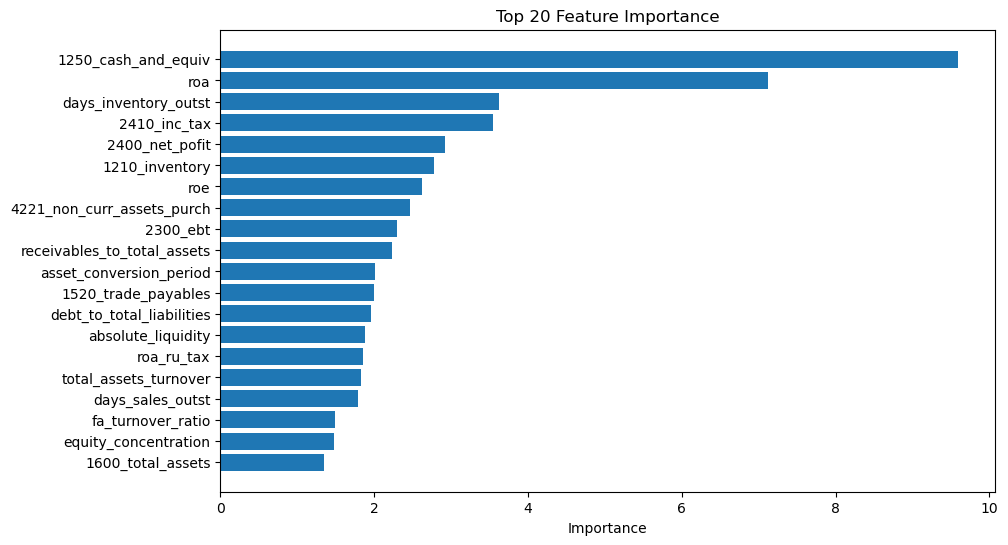

In [6]:
fi_df = get_most_important_features(model, show=20)

Обучение калибровки, подсчет ее метрик

На данных лучше всего показала себя калибрация Isotonic. Она меньше всего занижала вероятности в тестовой выборке, хотя они все равно были занижены (в тестовой выборке дефолтов больше в ~3 раза). У этой калибровки есть недостаток - схожим по вероятности контрагентам она может присваивать одинаковые вероятности, из-за своего ступенчатого вида.

В качестве альтернативы есть utils.common.calibrate_model_logistic - Logistic калибровка модели. Она представляет собой гладкую функцию, поэтому значения вероятности схожих контрагентов будут разными, но она чуть больше занижает вероятности относительно истины.

In [7]:
from utils.common import calibrate_model, calibrate_model_logistic

calibrated_model = calibrate_model(model, X_val, y_val)
# calibrated_model = calibrate_model_logistic(model, X_val, y_val)

In [8]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.8815872160351467
Brier: 0.012303456457221229
LogLoss: 0.059329922931332796


# Сохранение и загрузка эксперимента

In [9]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='big_df_no_lags',
         save_data=False)

'exp/big_df_no_lags'

Загрузка моделей из проведенного эксперимента

In [10]:
from utils.exp_handler import load_exp

load_dict = load_exp('exp/big_df_no_lags')
load_model = load_dict['model']
load_calibrated_model = load_dict['calibrated_model']

# Анализ модели

Построение waterfall графика

Predicted calibrated probability: 0.006951340615690168


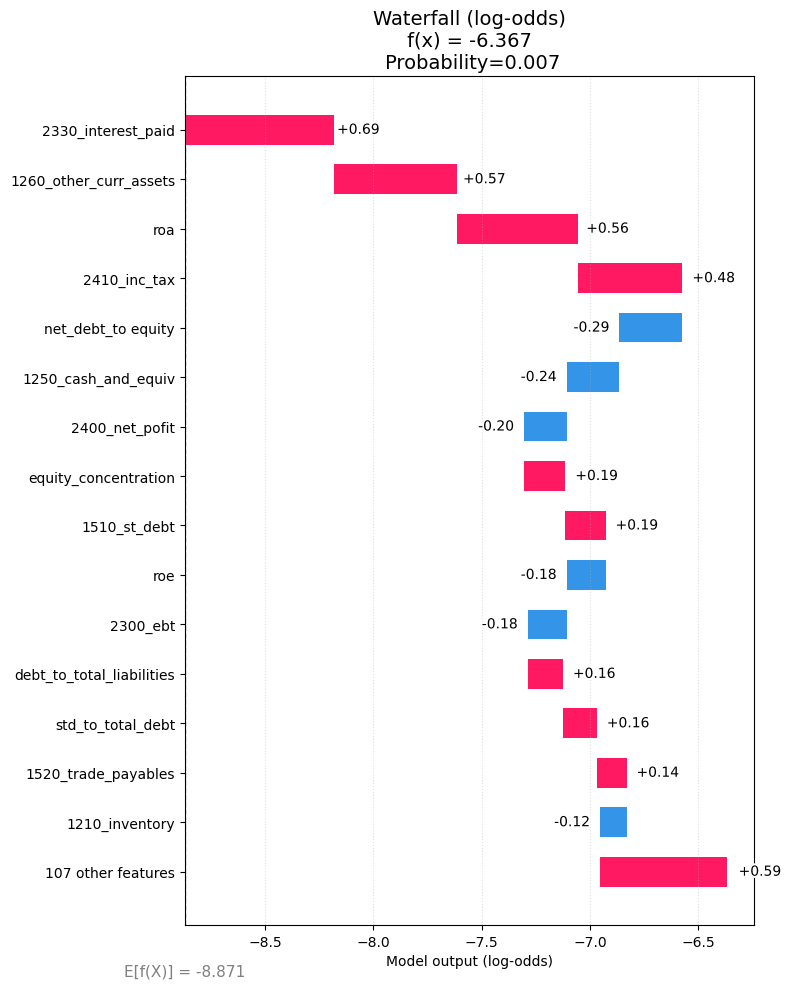

In [11]:
from utils.waterfall_graph import show_waterfall_graph


x0 = X_test.iloc[1]
show_waterfall_graph(load_model, load_calibrated_model, x0, top_k=15)


Распределение дефолта по годам

In [12]:
from utils.analysis import year_distribution

year_distribution(df)

      zeros  ones  target_0_pct  target_1_pct
year                                         
1999   2414     0        100.00          0.00
2000   2923     0        100.00          0.00
2001   3274     0        100.00          0.00
2002   3762     0        100.00          0.00
2003   4616     0        100.00          0.00
2004   5140     0        100.00          0.00
2005   5786     0        100.00          0.00
2006   6722     0        100.00          0.00
2007   7761     0        100.00          0.00
2008   8720     0        100.00          0.00
2009  10049     0        100.00          0.00
2010  11334     0        100.00          0.00
2011  12376     0        100.00          0.00
2012  17027     1         99.99          0.01
2013  20483     2         99.99          0.01
2014  24563    11         99.96          0.04
2015  29312    19         99.94          0.06
2016  33454    43         99.87          0.13
2017  37636    52         99.86          0.14
2018  42273    78         99.82   

Анализ ранжирования по децилям

In [13]:
from utils.analysis import decile_analysis

decile_analysis(calibrated_model, X_test, y_test, splits=10)

Lift / deciles table (0 = highest risk):
   decile    avg_pd  actual_default_rate  count  defaults
0       0  0.052304             0.091638   5609       514
1       1  0.009154             0.018367   5608       103
2       2  0.004617             0.011769   5608        66
3       3  0.001263             0.006598   5608        37
4       4  0.001088             0.005170   5609        29
5       5  0.000652             0.003210   5608        18
6       6  0.000222             0.001783   5608        10
7       7  0.000181             0.000892   5608         5
8       8  0.000130             0.000713   5608         4
9       9  0.000000             0.000535   5609         3
Top 10% default rate: 0.09165477888730385
Top 20% default rate: 0.055010699001426536
Overall default rate: 0.014068434284899168


Калибровочная кривая. Оранжевая линия - идеальная калибровка.

Calibration table:
                    bin  avg_pred_pd  actual_default_rate  count
0    (-0.001, 0.000137]     0.000070             0.000583  12004
1  (0.000137, 0.000188]     0.000188             0.001407   9948
2  (0.000188, 0.000578]     0.000578             0.002956   5075
3  (0.000578, 0.000985]     0.000984             0.004466   3135
4   (0.000985, 0.00126]     0.001221             0.006085   9203
5    (0.00126, 0.00695]     0.005040             0.012402   6531
6     (0.00695, 0.0181]     0.011265             0.022061   5666
7       (0.0181, 0.778]     0.060543             0.105508   4521


/home/jovyan/дефолт/inference/utils/analysis.py:54: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal_table = df_cal.groupby("bin").agg(


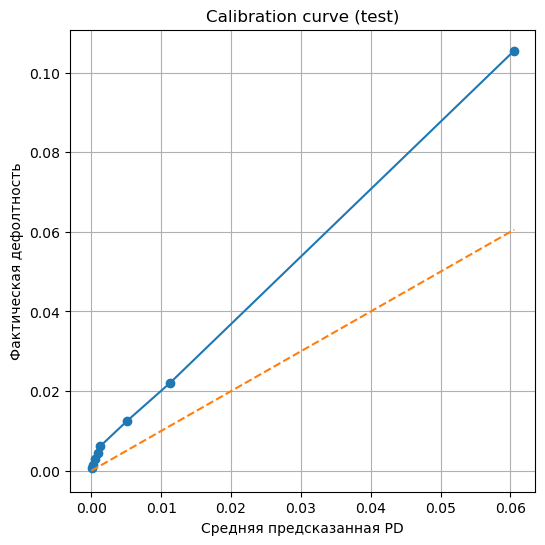

In [14]:
from utils.analysis import calibration_curve

calibration_curve(calibrated_model, X_test, y_test)